# **Disparity Refinement: WLS & Guided Filters**

## **Objectives:**
1. Post-process notebook 32's raw `StereoSGBM` disparity map with `cv2.ximgproc`'s edge-aware WLS filter and a generic guided filter — no external model, no new dependency
2. Measure something notebook 32 didn't: **density** — how much of the image actually got a disparity value at all
3. Find the real trade each filter makes against notebook 32/38's ground-truth correlation, not just "it looks smoother"

> **Assets.** No new files — reuses notebook 32's exact `assets/images/aloeL.jpg` / `aloeR.jpg` / `aloeGT.png`. `cv2.ximgproc`'s `createDisparityWLSFilter`, `createRightMatcher`, and `guidedFilter` all ship in the `opencv-contrib` wheel this repo already pins — zero setup changes.

In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

# Define our imshow function
def imshow(title = "Image", image = None, size = 10):
    w, h = image.shape[0], image.shape[1]
    aspect_ratio = w/h
    plt.figure(figsize=(size * aspect_ratio,size))
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.show()

## **What notebook 32 didn't measure: the holes**

`StereoSGBM` doesn't have to produce an answer for every pixel — where it can't find a confident match (occluded regions, flat texture-less patches), it leaves the disparity at 0, which notebook 32's correlation check quietly excluded (`valid = d > 0`). That's the right call for *accuracy*, but it hides how much of the image was actually left blank.

Raw StereoSGBM: 78.9% of the image has a disparity value at all
(21.1% is a hole — occluded or too flat to match confidently)


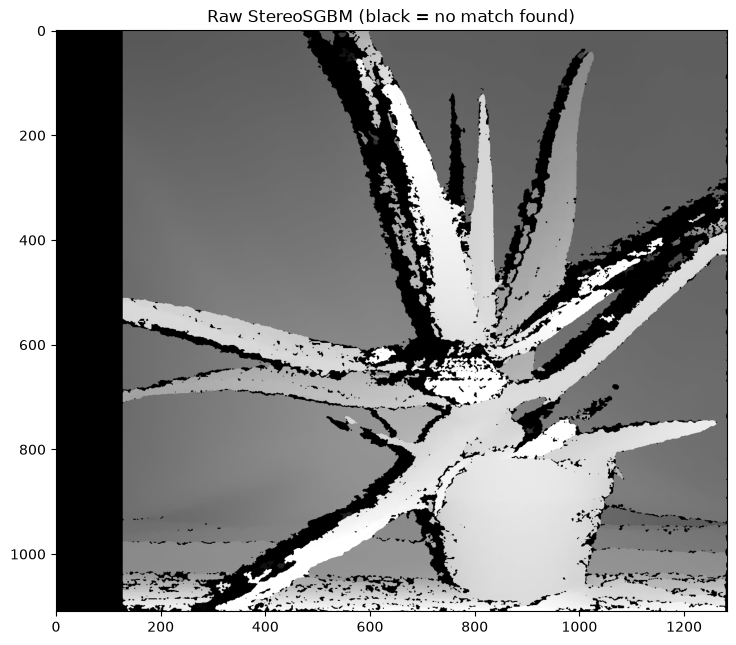

In [2]:
aloe_l = cv2.imread('assets/images/aloeL.jpg', cv2.IMREAD_GRAYSCALE)
aloe_r = cv2.imread('assets/images/aloeR.jpg', cv2.IMREAD_GRAYSCALE)
aloe_gt = cv2.imread('assets/images/aloeGT.png', cv2.IMREAD_GRAYSCALE)

num_disp = 16 * 8
left_matcher = cv2.StereoSGBM_create(
    minDisparity=0, numDisparities=num_disp, blockSize=5,
    P1=8 * 3 * 5 ** 2, P2=32 * 3 * 5 ** 2,
    disp12MaxDiff=1, uniquenessRatio=10,
    speckleWindowSize=100, speckleRange=32,
)
disp_raw = left_matcher.compute(aloe_l, aloe_r).astype(np.float32) / 16.0

density_raw = (disp_raw > 0).mean()
print(f'Raw StereoSGBM: {density_raw * 100:.1f}% of the image has a disparity value at all')
print(f'({(1 - density_raw) * 100:.1f}% is a hole — occluded or too flat to match confidently)')

def normalize_disp(d):
    return cv2.normalize(np.clip(d, 0, None), None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

imshow('Raw StereoSGBM (black = no match found)', normalize_disp(disp_raw))

## **WLS filter: fills holes using the original photo as a guide**

`createRightMatcher` runs the same matcher right-to-left too — comparing the left-to-right and right-to-left results against each other is exactly how the WLS filter builds a *confidence map* internally: where both directions agree, trust the disparity; where they don't (or one side has no match), lean harder on smoothing, guided by edges in the original left photo so the fill-in doesn't bleed across a real object boundary.

WLS-filtered: 89.3% of the image now has a disparity value


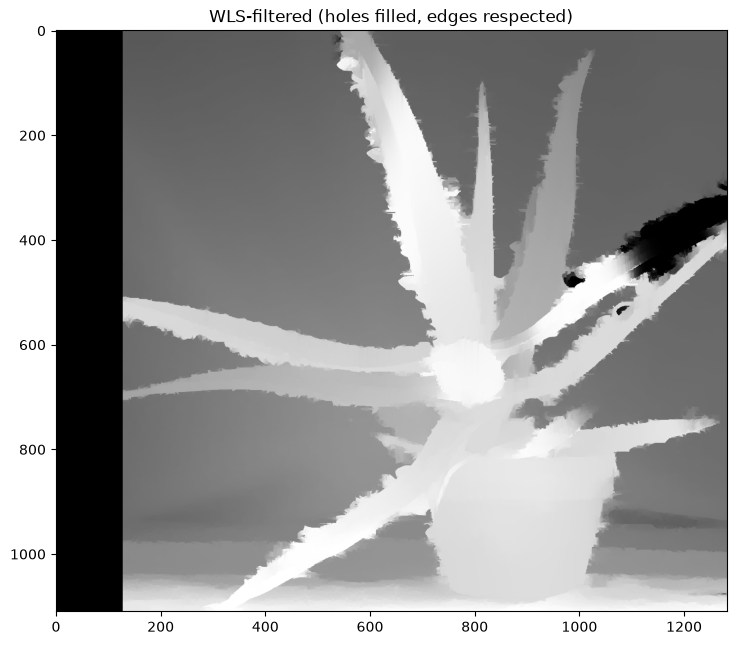

In [3]:
right_matcher = cv2.ximgproc.createRightMatcher(left_matcher)
disp_left_raw = left_matcher.compute(aloe_l, aloe_r)   # keep the raw CV_16S output — WLS wants it unscaled
disp_right_raw = right_matcher.compute(aloe_r, aloe_l)

wls = cv2.ximgproc.createDisparityWLSFilter(left_matcher)
wls.setLambda(8000)      # OpenCV's own documented default for this filter
wls.setSigmaColor(1.5)
disp_wls = wls.filter(disp_left_raw, aloe_l, disparity_map_right=disp_right_raw).astype(np.float32) / 16.0

density_wls = (disp_wls > 0).mean()
print(f'WLS-filtered: {density_wls * 100:.1f}% of the image now has a disparity value')
imshow('WLS-filtered (holes filled, edges respected)', normalize_disp(disp_wls))

## **Guided filter: the same idea, without knowing what's a hole**

`guidedFilter` is a general-purpose edge-preserving smoother (the same tool notebook 8's bilateral filter is often swapped for) — apply it directly to the raw disparity map, guided by the left photo, with no special handling for which pixels are real matches versus holes.

Guided-filtered: 90.1% of the image now has a disparity value


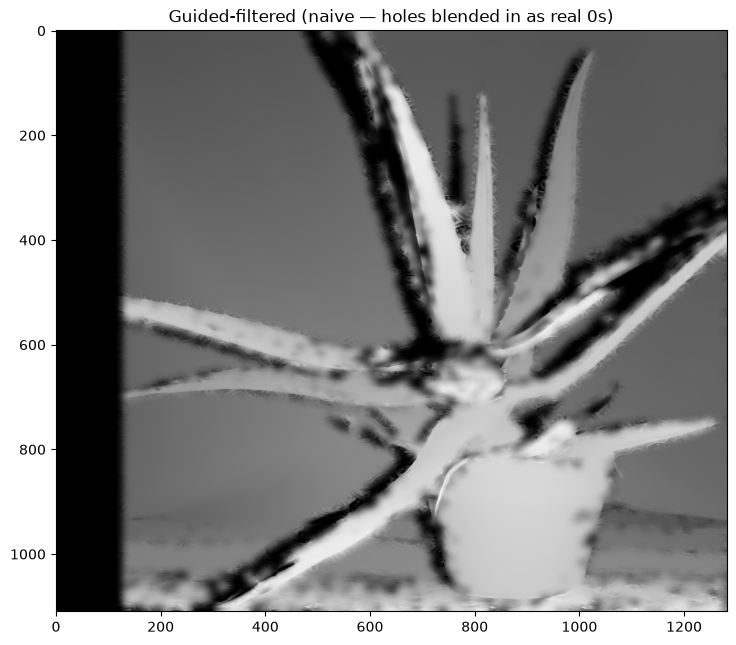

In [4]:
disp_guided = cv2.ximgproc.guidedFilter(guide=aloe_l, src=disp_raw, radius=8, eps=100)
density_guided = (disp_guided > 0).mean()
print(f'Guided-filtered: {density_guided * 100:.1f}% of the image now has a disparity value')
imshow('Guided-filtered (naive — holes blended in as real 0s)', normalize_disp(disp_guided))

## **Scoring all three — density *and* accuracy**

Reusing notebook 32/38's exact `masked_corr` foreground check (against real, independently-measured `aloeGT.png`), now paired with density.

In [5]:
def masked_corr(disp, gt, mask):
    d, g = disp[mask], gt[mask].astype(np.float32)
    valid = d > 0
    if valid.sum() < 2 or g[valid].std() == 0:
        return None
    return np.corrcoef(d[valid], g[valid])[0, 1]

foreground = aloe_gt >= 40

for name, disp in [('Raw StereoSGBM', disp_raw), ('Guided filter (naive)', disp_guided), ('WLS filter', disp_wls)]:
    density = (disp > 0).mean()
    corr = masked_corr(disp, aloe_gt, foreground)
    print(f'{name:22s}  density={density*100:5.1f}%   foreground corr={corr:.3f}')

Raw StereoSGBM          density= 78.9%   foreground corr=0.933
Guided filter (naive)   density= 90.1%   foreground corr=0.647
WLS filter              density= 89.3%   foreground corr=0.869


## **The real trade-off**

Raw `StereoSGBM` wins on correlation but leaves real gaps — about a fifth of the image has no answer at all. Both filters close most of that gap, but not equally well: the **naive guided filter** treats a hole's placeholder value of 0 as if it were a genuine "very close" disparity reading and blends it into real neighboring values, dragging accuracy down hard. The **WLS filter** does noticeably better at the same job because it isn't naive about which pixels to trust — its internal left-right confidence check means the smoothing leans on genuinely reliable neighbors, not on the holes themselves.

Neither filter is a strict upgrade over the raw map — this is the same kind of honest trade notebook 35 found between bicubic and learned super-resolution: raw `StereoSGBM` is best when you can afford real gaps and only want its most confident answers; WLS is best when a downstream step (a 3D reconstruction, a point cloud, anything that can't tolerate missing pixels) genuinely needs a complete map and can accept a modest accuracy cost on the pixels it had to guess.

### Worth a second look

- Mask out the holes (`disp_raw > 0`) *before* guided-filtering, so it only ever smooths real values — check whether that closes most of the gap to WLS's accuracy.
- Sweep `setLambda` from 500 to 16000 (this notebook used OpenCV's documented default, 8000) — lower values trust the raw matcher more and fill less aggressively; find where density and correlation actually cross.
- Feed `disp_wls` through notebook 32's `Z = f * B / d` conversion and `cv2.reprojectImageTo3D` — a genuinely complete depth map (no holes) is exactly what that kind of 3D reconstruction needs and the raw map can't offer.